# MovieLens Latest Small — Preprocessing
**Goal:** Filter cold items, remap IDs to dense indices, train/test split, and save clean artefacts.

No rating transformations — ratings are ordinal labels, not features. Missing entries are not filled — they're what we're trying to predict.


## 1. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── plot style ────────────────────────────────
BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

# ── paths ─────────────────────────────────────
RATINGS_PATH = "../data/raw/ratings.csv"
MOVIES_PATH  = "../data/raw/movies.csv"

# ── preprocessing knobs ───────────────────────
MIN_MOVIE_RATINGS = 10   # drop movies with fewer ratings than this
MIN_USER_RATINGS  = 5    # drop users with fewer ratings than this (already ≥20 here)
TEST_FRAC         = 0.2
SEED              = 42


## 2. Load Raw Data

In [2]:
ratings_raw = pd.read_csv(RATINGS_PATH)
movies_raw  = pd.read_csv(MOVIES_PATH)

ratings_raw["timestamp"] = pd.to_datetime(ratings_raw["timestamp"], unit="s")

print(f"Raw ratings : {len(ratings_raw):,}")
print(f"Raw users   : {ratings_raw.userId.nunique():,}")
print(f"Raw movies  : {ratings_raw.movieId.nunique():,}")
print()
print(ratings_raw.head())


Raw ratings : 100,836
Raw users   : 610
Raw movies  : 9,724

   userId  movieId  rating           timestamp
0       1        1     4.0 2000-07-30 18:45:03
1       1        3     4.0 2000-07-30 18:20:47
2       1        6     4.0 2000-07-30 18:37:04
3       1       47     5.0 2000-07-30 19:03:35
4       1       50     5.0 2000-07-30 18:48:51


## 3. Extract Year from Title

Movie titles in this dataset embed the release year: `"Toy Story (1995)"`.  
We parse it out as a separate column — useful for later analysis and potentially as a feature.


In [3]:
movies = movies_raw.copy()

# Extract year with regex — handles titles like "Toy Story (1995)"
movies["year"] = movies["title"].str.extract(r'\((\d{4})\)$').astype(float)

# Clean title: strip the " (YYYY)" suffix
movies["title_clean"] = movies["title"].str.replace(r'\s*\(\d{4}\)$', '', regex=True).str.strip()

# Parse genres into a list
movies["genre_list"] = movies["genres"].str.split("|")

missing_year = movies["year"].isna().sum()
print(f"Movies with parseable year : {movies.year.notna().sum():,}")
print(f"Movies missing year        : {missing_year}")
print()
print(movies.head())


Movies with parseable year : 9,718
Movies missing year        : 24

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres    year  \
0  Adventure|Animation|Children|Comedy|Fantasy  1995.0   
1                   Adventure|Children|Fantasy  1995.0   
2                               Comedy|Romance  1995.0   
3                         Comedy|Drama|Romance  1995.0   
4                                       Comedy  1995.0   

                   title_clean  \
0                    Toy Story   
1                      Jumanji   
2             Grumpier Old Men   
3            Waiting to Exhale   
4  Father of the Bride Part II   

                                          genre_list  
0  [Adventure, Animati

## 4. Cold-Start Filtering

Drop movies and users below minimum interaction thresholds.  
We apply this **iteratively** — dropping cold movies may make some users cold, and vice versa.  
We loop until the dataset stabilises.


In [4]:
ratings = ratings_raw.copy()

iteration = 0
while True:
    before = len(ratings)

    # Drop cold movies
    movie_counts = ratings.groupby("movieId")["rating"].count()
    valid_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index
    ratings = ratings[ratings["movieId"].isin(valid_movies)]

    # Drop cold users
    user_counts = ratings.groupby("userId")["rating"].count()
    valid_users = user_counts[user_counts >= MIN_USER_RATINGS].index
    ratings = ratings[ratings["userId"].isin(valid_users)]

    iteration += 1
    after = len(ratings)
    print(f"  Iteration {iteration}: {before:,} → {after:,} ratings")
    if before == after:
        break

print()
print(f"{'':30} {'BEFORE':>10}  {'AFTER':>10}  {'DROPPED':>10}")
print(f"  {'Ratings':<28} {len(ratings_raw):>10,}  {len(ratings):>10,}  {len(ratings_raw)-len(ratings):>10,}")
print(f"  {'Users':<28} {ratings_raw.userId.nunique():>10,}  {ratings.userId.nunique():>10,}  {ratings_raw.userId.nunique()-ratings.userId.nunique():>10,}")
print(f"  {'Movies':<28} {ratings_raw.movieId.nunique():>10,}  {ratings.movieId.nunique():>10,}  {ratings_raw.movieId.nunique()-ratings.movieId.nunique():>10,}")

sparsity_before = 1 - len(ratings_raw) / (ratings_raw.userId.nunique() * ratings_raw.movieId.nunique())
sparsity_after  = 1 - len(ratings)     / (ratings.userId.nunique()      * ratings.movieId.nunique())
print(f"  {'Sparsity':<28} {sparsity_before:>10.3%}  {sparsity_after:>10.3%}")


  Iteration 1: 100,836 → 81,116 ratings
  Iteration 2: 81,116 → 81,116 ratings

                                   BEFORE       AFTER     DROPPED
  Ratings                         100,836      81,116      19,720
  Users                               610         610           0
  Movies                            9,724       2,269       7,455
  Sparsity                        98.300%     94.139%


## 5. Visualise Filter Impact

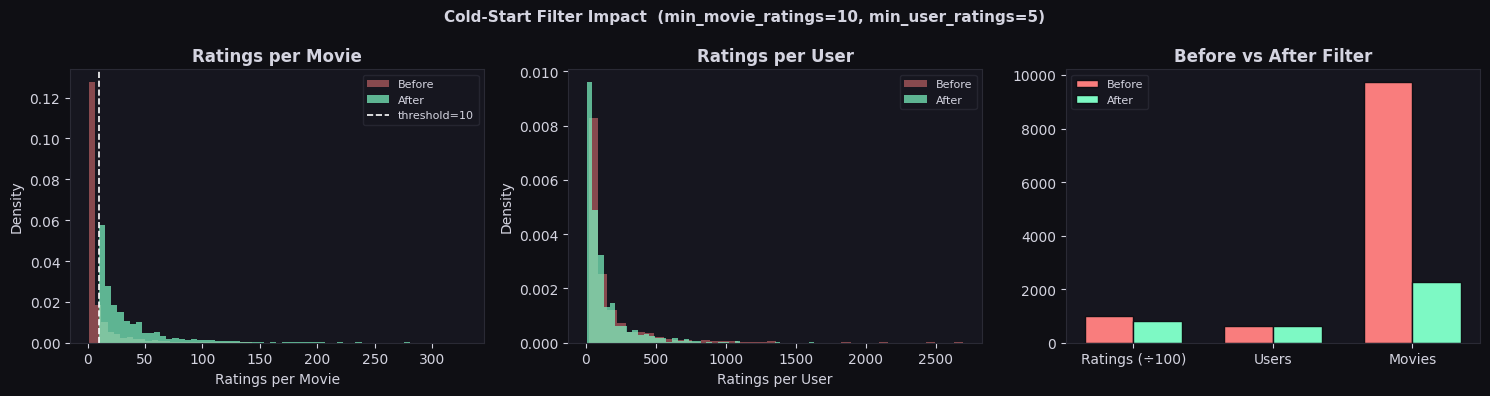

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor(BG)

# ratings per movie: before vs after
ax = axes[0]
ax.set_facecolor(PANEL)
rpm_before = ratings_raw.groupby("movieId")["rating"].count()
rpm_after  = ratings.groupby("movieId")["rating"].count()
ax.hist(rpm_before, bins=60, color=ACCENT2, alpha=0.5, label="Before", density=True)
ax.hist(rpm_after,  bins=60, color=ACCENT,  alpha=0.7, label="After",  density=True)
ax.axvline(MIN_MOVIE_RATINGS, color="white", lw=1.2, linestyle="--",
           label=f"threshold={MIN_MOVIE_RATINGS}")
ax.set_xlabel("Ratings per Movie", color=TEXT_C)
ax.set_ylabel("Density", color=TEXT_C)
ax.set_title("Ratings per Movie", color=TEXT_C, fontweight="bold")
ax.tick_params(colors=TEXT_C)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)

# ratings per user: before vs after
ax = axes[1]
ax.set_facecolor(PANEL)
rpu_before = ratings_raw.groupby("userId")["rating"].count()
rpu_after  = ratings.groupby("userId")["rating"].count()
ax.hist(rpu_before, bins=40, color=ACCENT2, alpha=0.5, label="Before", density=True)
ax.hist(rpu_after,  bins=40, color=ACCENT,  alpha=0.7, label="After",  density=True)
ax.set_xlabel("Ratings per User", color=TEXT_C)
ax.set_ylabel("Density", color=TEXT_C)
ax.set_title("Ratings per User", color=TEXT_C, fontweight="bold")
ax.tick_params(colors=TEXT_C)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)

# bar chart: counts before vs after
ax = axes[2]
ax.set_facecolor(PANEL)
categories = ["Ratings (÷100)", "Users", "Movies"]
before_vals = [len(ratings_raw)/100, ratings_raw.userId.nunique(), ratings_raw.movieId.nunique()]
after_vals  = [len(ratings)/100,     ratings.userId.nunique(),     ratings.movieId.nunique()]
x = np.arange(len(categories))
w = 0.35
ax.bar(x - w/2, before_vals, w, color=ACCENT2, label="Before", edgecolor=BG)
ax.bar(x + w/2, after_vals,  w, color=ACCENT,  label="After",  edgecolor=BG)
ax.set_xticks(x); ax.set_xticklabels(categories, color=TEXT_C)
ax.tick_params(colors=TEXT_C)
ax.set_title("Before vs After Filter", color=TEXT_C, fontweight="bold")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)

fig.suptitle(f"Cold-Start Filter Impact  (min_movie_ratings={MIN_MOVIE_RATINGS}, min_user_ratings={MIN_USER_RATINGS})",
             color=TEXT_C, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Remap IDs to Dense 0-Based Indices

Raw IDs are arbitrary integers (movieId goes up to 193,609).  
We need **dense 0-based indices** to index into the P and Q matrices in our MF model.  
We save the mappings so we can decode predictions back to real movie titles later.


In [6]:
# Build encoders
user_ids  = sorted(ratings["userId"].unique())
movie_ids = sorted(ratings["movieId"].unique())

user_to_idx  = {uid: i for i, uid in enumerate(user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}

# Inverse maps — for decoding predictions
idx_to_user  = {i: uid for uid, i in user_to_idx.items()}
idx_to_movie = {i: mid for mid, i in movie_to_idx.items()}

# Apply to ratings
ratings = ratings.copy()
ratings["user_idx"]  = ratings["userId"].map(user_to_idx)
ratings["movie_idx"] = ratings["movieId"].map(movie_to_idx)

n_users  = len(user_to_idx)
n_movies = len(movie_to_idx)

print(f"n_users  = {n_users}")
print(f"n_movies = {n_movies}")
print(f"user_idx  range: {ratings.user_idx.min()} – {ratings.user_idx.max()}")
print(f"movie_idx range: {ratings.movie_idx.min()} – {ratings.movie_idx.max()}")
print()
print(ratings[["userId","user_idx","movieId","movie_idx","rating"]].head(8))


n_users  = 610
n_movies = 2269
user_idx  range: 0 – 609
movie_idx range: 0 – 2268

   userId  user_idx  movieId  movie_idx  rating
0       1         0        1          0     4.0
1       1         0        3          2     4.0
2       1         0        6          4     4.0
3       1         0       47         34     5.0
4       1         0       50         36     5.0
5       1         0       70         43     3.0
6       1         0      101         55     5.0
7       1         0      110         59     4.0


## 7. Train / Test Split

**Per-user temporal holdout**: for each user, we hold out the most recent 20% of their ratings as the test set, and use the older 80% for training.

This guarantees:
- Every user appears in both train and test (no cold-start leakage)
- The model always trains on past ratings and predicts future ones — mirrors real deployment

In [ ]:
train_rows, test_rows = [], []

for _, group in ratings.groupby("user_idx"):
    group = group.sort_values("timestamp")   # sort by time instead of shuffle
    split = max(1, int(len(group) * TEST_FRAC))
    test_rows.extend(group.index[-split:])   # most recent 20% → test
    train_rows.extend(group.index[:-split])  # older 80% → train

train = ratings.loc[train_rows].reset_index(drop=True)
test  = ratings.loc[test_rows].reset_index(drop=True)

print(f"Train : {len(train):,} ratings")
print(f"Test  : {len(test):,}  ratings")
print(f"Split : {len(test)/(len(train)+len(test)):.1%} test")
print()

# Sanity checks
assert set(test.user_idx) <= set(train.user_idx), "Cold-start users in test!"
print("✓ All test users appear in train")
print(f"✓ Train users: {train.user_idx.nunique()}  |  Test users: {test.user_idx.nunique()}")

# Verify temporal ordering — train timestamps should be earlier than test
train_max_ts = train.groupby("user_idx")["timestamp"].max()
test_min_ts  = test.groupby("user_idx")["timestamp"].min()
assert (train_max_ts <= test_min_ts).all(), "Temporal leakage detected!"
print("✓ No temporal leakage — all train ratings are older than test ratings per user")

# Ratings per user in train vs test
train_rpu = train.groupby("user_idx")["rating"].count()
test_rpu  = test.groupby("user_idx")["rating"].count()
print(f"\nTrain ratings/user — min: {train_rpu.min()}  median: {train_rpu.median():.0f}  max: {train_rpu.max()}")
print(f"Test  ratings/user — min: {test_rpu.min()}   median: {test_rpu.median():.0f}  max: {test_rpu.max()}")

## 8. Final Summary & Save Artefacts

In [8]:
print("=" * 50)
print("  Preprocessed Dataset Summary")
print("=" * 50)
print(f"  Users        : {n_users:,}")
print(f"  Movies       : {n_movies:,}")
print(f"  Total ratings: {len(ratings):,}")
print(f"  Sparsity     : {1 - len(ratings)/(n_users*n_movies):.3%}")
print(f"  Rating range : {ratings.rating.min()} – {ratings.rating.max()}")
print(f"  Global mean  : {ratings.rating.mean():.4f}")
print()
print(f"  Train        : {len(train):,}")
print(f"  Test         : {len(test):,}")
print("=" * 50)

# Save
train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv",   index=False)

# Save the filtered movies table (with year + clean title)
movies_filtered = movies[movies["movieId"].isin(movie_to_idx.keys())].copy()
movies_filtered["movie_idx"] = movies_filtered["movieId"].map(movie_to_idx)
movies_filtered.to_csv("../data/processed/movies_clean.csv", index=False)

# Save ID maps as CSVs (useful for decoding later)
pd.DataFrame({"userId": user_ids,  "user_idx":  range(n_users)}).to_csv("../data/processed/user_map.csv",  index=False)
pd.DataFrame({"movieId": movie_ids, "movie_idx": range(n_movies)}).to_csv("../data/processed/movie_map.csv", index=False)

print("\nSaved: ../data/processed/train.csv, ../data/processed/test.csv, ../data/processed/movies_clean.csv, ../data/processed/user_map.csv, ../data/processed/movie_map.csv")


  Preprocessed Dataset Summary
  Users        : 610
  Movies       : 2,269
  Total ratings: 81,116
  Sparsity     : 94.139%
  Rating range : 0.5 – 5.0
  Global mean  : 3.5737

  Train        : 65,130
  Test         : 15,986

Saved: train.csv, test.csv, movies_clean.csv, user_map.csv, movie_map.csv
